In [ ]:
# gpu verification
import torch
import torch_directml

# Check if DirectML is available
if torch_directml.is_available():
    print("Success! AMD GPU is visible via DirectML.")
    # Set the device to the AMD GPU
    device = torch_directml.device()
    print(f"Device name: {torch_directml.device_name(0)}")
else:
    print("DirectML is not detecting the GPU. It will default to CPU.")
    device = torch.device("cpu")

Success! AMD GPU is visible via DirectML.
Device name: AMD Radeon RX 9060 XT 


In [ ]:
import pandas as pd
import numpy as np
import torch
import torch_directml
from transformers import AutoTokenizer, AutoModel
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import os
import pickle
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm

print("Initializing GPU...")
device = torch_directml.device()
print(f"Success! Using DirectML Device: {torch_directml.device_name(0)}")

Initializing GPU...
Success! Using DirectML Device: AMD Radeon RX 9060 XT 


In [25]:
# loading dataset
print("Loading dataset...")
df = pd.read_csv('dataset/Truth_Seeker_Model_Dataset.csv')

df = df.dropna(subset=['tweet', 'BinaryNumTarget']).copy()
df['BinaryNumTarget'] = df['BinaryNumTarget'].astype(int)
df = df.sample(n=10000, random_state=42).copy()

Loading dataset...


In [ ]:
# cache
CACHE_FILE = 'embeddings_cache_directml.pkl'

if os.path.exists(CACHE_FILE):
    print(f"Found existing cache! Loading from {CACHE_FILE}...")
    with open(CACHE_FILE, 'rb') as f:
        embeddings_cache = pickle.load(f)
    print(f"Loaded {len(embeddings_cache)} previously processed embeddings.")
else:
    print("No cache found. Starting fresh.")
    embeddings_cache = {}

df_to_process = df[~df.index.isin(embeddings_cache.keys())]
print(f"Remaining tweets to process: {len(df_to_process)}")

Found existing cache! Loading from embeddings_cache_directml.pkl...
Loaded 10000 previously processed embeddings.
Remaining tweets to process: 0


In [ ]:
# BERT
model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name).to(device)
model.eval() 

# Custom Dataset for PyTorch DataLoader
class TweetDataset(Dataset):
    def __init__(self, texts, indices):
        self.texts = texts
        self.indices = indices

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        return self.texts[idx], self.indices[idx]

if len(df_to_process) > 0:
    # 64 is a great starting point for a 16GB VRAM card like the 6900 XT
    BATCH_SIZE = 64 
    SAVE_EVERY_N_BATCHES = 50 

    dataset = TweetDataset(df_to_process['tweet'].tolist(), df_to_process.index.tolist())
    dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)

    print("Extracting new embeddings via AMD GPU...")
    for batch_num, (batch_texts, batch_indices) in enumerate(tqdm(dataloader)):
        
        # Tokenize the batch and move to AMD GPU
        inputs = tokenizer(list(batch_texts), padding=True, truncation=True, max_length=128, return_tensors="pt")
        inputs = {k: v.to(device) for k, v in inputs.items()}
        
        # Pass batch through BERT
        with torch.no_grad():
            outputs = model(**inputs)
        
        # Extract [CLS] tokens and move them back to standard CPU memory as NumPy arrays
        cls_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        
        # Store in cache dictionary mapping original DataFrame index to its embedding
        for i, idx in enumerate(batch_indices):
            embeddings_cache[idx.item()] = cls_embeddings[i]
            
        # Save cache periodically 
        if (batch_num + 1) % SAVE_EVERY_N_BATCHES == 0:
            with open(CACHE_FILE, 'wb') as f:
                pickle.dump(embeddings_cache, f)

    # Final save after the loop finishes
    with open(CACHE_FILE, 'wb') as f:
        pickle.dump(embeddings_cache, f)
    print("All embeddings extracted and saved!")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
# SVM
print("Preparing data for SVM...")
# Map the vectors back to their exact original rows
df['embeddings'] = df.index.map(embeddings_cache)
df_clean = df.dropna(subset=['embeddings']).copy()

X = np.stack(df_clean['embeddings'].values)
y = df_clean['BinaryNumTarget'].values

print(f"Training SVM on {len(X)} samples using 5-Fold Cross-Validation...")
# Using probability=True so we can calculate ROC-AUC
svm_classifier = SVC(kernel='linear', probability=True, random_state=42)
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

accs, precs, recs, f1s, aucs = [], [], [], [], []

for fold, (train_index, test_index) in enumerate(kf.split(X, y), 1):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    svm_classifier.fit(X_train, y_train)
    
    y_pred = svm_classifier.predict(X_test)
    y_prob = svm_classifier.predict_proba(X_test)[:, 1]
    
    accs.append(accuracy_score(y_test, y_pred))
    precs.append(precision_score(y_test, y_pred, zero_division=0))
    recs.append(recall_score(y_test, y_pred, zero_division=0))
    f1s.append(f1_score(y_test, y_pred, zero_division=0))
    aucs.append(roc_auc_score(y_test, y_prob))
    
    print(f"Fold {fold} Complete - Accuracy: {accs[-1]:.4f}")

Preparing data for SVM...
Training SVM on 10000 samples using 5-Fold Cross-Validation...
Fold 1 Complete - Accuracy: 0.7750
Fold 2 Complete - Accuracy: 0.7980
Fold 3 Complete - Accuracy: 0.7845
Fold 4 Complete - Accuracy: 0.7815
Fold 5 Complete - Accuracy: 0.7800


In [ ]:
# metrics
print("\n=== Final Average Metrics (5 Folds) ===")
print(f"Accuracy:  {np.mean(accs):.4f}")
print(f"Precision: {np.mean(precs):.4f}")
print(f"Recall:    {np.mean(recs):.4f}")
print(f"F1-Score:  {np.mean(f1s):.4f}")
print(f"ROC-AUC:   {np.mean(aucs):.4f}")



=== Final Average Metrics (5 Folds) ===
Accuracy:  0.7838
Precision: 0.7900
Recall:    0.7937
F1-Score:  0.7918
ROC-AUC:   0.8633


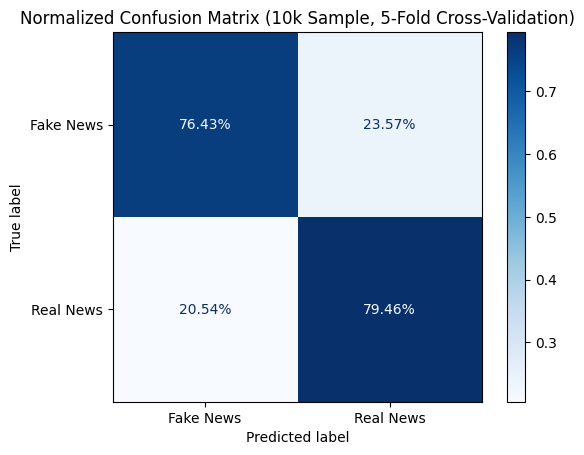

In [ ]:
# confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=['Fake News', 'Real News'], 
    cmap='Blues', 
    normalize='true',
    values_format='.2%'
)

plt.title('Normalized Confusion Matrix (10k Sample, 5-Fold Cross-Validation)')
plt.show()

In [ ]:
# examples
import pandas as pd

test_tweets = df_clean.iloc[test_index]['tweet'].values
y_margin = svm_classifier.decision_function(X_test)

results_df = pd.DataFrame({
    'tweet': test_tweets,
    'Actual': y_test,
    'Predicted': y_pred
})

TP = results_df[(results_df['Actual'] == 1) & (results_df['Predicted'] == 1)]
TN = results_df[(results_df['Actual'] == 0) & (results_df['Predicted'] == 0)]
FP = results_df[(results_df['Actual'] == 0) & (results_df['Predicted'] == 1)]
FN = results_df[(results_df['Actual'] == 1) & (results_df['Predicted'] == 0)]

TP_sample = TP.sample(n=2, random_state=42)
TN_sample = TN.sample(n=2, random_state=42)
FP_sample = FP.sample(n=2, random_state=42)
FN_sample = FN.sample(n=2, random_state=42)

print("TP\n----------------------------")
for i, row in enumerate(TP_sample.itertuples(), 1): 
    print(f"Text: {row.tweet}\n")

print("TN\n----------------------------")
for i, row in enumerate(TN_sample.itertuples(), 1): 
    print(f"Text: {row.tweet}\n")

print("FP\n----------------------------")
for i, row in enumerate(FP_sample.itertuples(), 1): 
    print(f"Text: {row.tweet}\n")

print("FN\n----------------------------")
for i, row in enumerate(FN_sample.itertuples(), 1): 
    print(f"Text: {row.tweet}\n")

TP
----------------------------
Text: @realTuckFrumper He can probably afford the special medication like trump was helped with Convalescent plasma therapy. Only certain people can afford to receive it.

Text: @Alan_Krueger We will see. Over a longer horizon, the trends are disappointing. Real wages have barely budged since the '70s.

TN
----------------------------
Text: @alliemom1 @theoldrepublic @SenSanders @realDonaldTrump @POTUS @GOP @GOPChairwoman Again go ahead and believe that. I believe up until negotiations were called off there was an offer of 1.9 trillion towards the package but still it was turned down. No stimulus no Trump signature on the checks and no chance of him getting votes because of it.

Text: @Stvrob_63 @kirstiealley This from the CDC website
In addition, a growing body of evidence suggests that mRNA COVID-19 vaccines also reduce asymptomatic infection and transmission.

FP
----------------------------
Text: @sacbee_news Sure Would've Been Great If The Same Agre